In [56]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *


In [144]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_map(lat, lon, data, *, lat_range=None, lon_range=None,
             box_color="black", box_linewidth=2, box_linestyle="-",
             central_longitude=210, vmin=None, vmax=None, cmap="bwr",
             boundary=None,):

    # Accept a single (south, north)/(west, east) pair or several pairs.
    # Each latitude range must have one corresponding longitude range.
    if (lat_range is None) != (lon_range is None):
        raise ValueError("Supply both lat_range and lon_range, or neither.")

    boxes_lat, boxes_lon = [], []
    if lat_range is not None:
        boxes_lat = np.atleast_2d(np.asarray(lat_range, dtype=float))
        boxes_lon = np.atleast_2d(np.asarray(lon_range, dtype=float))
        if (boxes_lat.ndim != 2 or boxes_lat.shape[1] != 2
                or boxes_lon.shape != boxes_lat.shape):
            raise ValueError("Supply matching latitude/longitude pairs with shape (number_of_boxes, 2).")
        if not np.isfinite(boxes_lat).all() or not np.isfinite(boxes_lon).all():
            raise ValueError("Box bounds must be finite.")
        if np.any((boxes_lat[:, 0] < -90) | (boxes_lat[:, 1] > 90)
                  | (boxes_lat[:, 0] > boxes_lat[:, 1])):
            raise ValueError("Latitude bounds must satisfy -90 <= south <= north <= 90.")
        if np.any(np.abs(boxes_lon[:, 1] - boxes_lon[:, 0]) > 360):
            raise ValueError("Longitude ranges cannot span more than 360 degrees.")

    # Plot the original field; boxes do not subset, reorder, or mask the data.
    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(central_longitude=central_longitude)})
    im = ax.pcolormesh(lon, lat, data, shading="auto", transform=ccrs.PlateCarree(),
                      vmin=vmin, vmax=vmax, cmap=cmap)
    ax.coastlines()
    style = dict(color=box_color, linewidth=box_linewidth, linestyle=box_linestyle,
                 transform=ccrs.PlateCarree(), zorder=5)

    # Draw each box eastward from west to east, including wrapped longitude ranges.
    # Dense boundary points keep the edges following latitude/longitude lines.
    for (south, north), (west, east) in zip(boxes_lat, boxes_lon):
        width = 360 if np.isclose(abs(east - west), 360) else (east - west) % 360
        west = (west + 180) % 360 - 180
        box_lon = np.linspace(west, west + width, 361)
        box_lat = np.linspace(south, north, 181)

        for latitude in [south, north]:
            ax.plot(box_lon, np.full_like(box_lon, latitude), **style)
        for longitude in [west, west + width]:
            ax.plot(np.full_like(box_lat, longitude), box_lat, **style)

    # Connect polygon corners, including the final corner back to the first.
    # Sample each edge so the diagonal follows a straight line in lon/lat coordinates.
    if boundary is not None:
        corners = np.asarray(boundary, dtype=float)
        for start, end in zip(corners, np.roll(corners, -1, axis=0)):
            edge = np.linspace(start, end, 101)
            ax.plot(edge[:, 0], edge[:, 1], transform=ccrs.PlateCarree(),
                    color=box_color, linewidth=box_linewidth,
                    linestyle=box_linestyle, zorder=5)
    ax.set_global()
    fig.colorbar(im, ax=ax)
    plt.show()
    return fig, ax

In [7]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs

# def plot_map(lat, lon, data):
#     fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(central_longitude=210)})
#     im = ax.pcolormesh(lon, lat, data, shading="auto", transform=ccrs.PlateCarree())
#     ax.coastlines()
#     fig.colorbar(im, ax=ax)
#     plt.show()
#     return fig, ax

In [58]:
import numpy as np

def lat_lon_indices(lat, lon, lat_range=(-90, 90), lon_range=(0, 360)):
    """Return 1-D latitude/longitude indices; bounds include grid-cell centers."""
    lat, lon = np.asarray(lat), np.asarray(lon)
    south, north = lat_range
    west, east = lon_range

    if south > north:
        raise ValueError("lat_range must be (south, north).")
    if abs(east - west) > 360:
        raise ValueError("Longitude range cannot span more than 360 degrees.")

    # Latitude selection does not depend on whether coordinates ascend or descend.
    lat_keep = np.isfinite(lat) & (lat >= south) & (lat <= north)

    # Measure each longitude's eastward distance from the western boundary.
    # Modulo handles both longitude conventions and ranges crossing 0 degrees.
    width = (east - west) % 360
    distance = (lon - west) % 360
    lon_keep = np.isfinite(lon) & (distance <= width)

    # Explicit full-circle bounds, e.g. (0, 360) or (-180, 180), include all longitudes.
    if np.isclose(abs(east - west), 360):
        lon_keep = np.isfinite(lon)

    return np.flatnonzero(lat_keep), np.flatnonzero(lon_keep)

In [59]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon
reference_grid = ERA5['tas'].isel(time=0).load()

raw_weights     = np.cos(np.deg2rad(lat.values))[:, None] * np.ones(reference_grid.shape)
raw_weights     = np.where(np.isfinite(reference_grid.values), raw_weights, 0.)
global_weights  = raw_weights / raw_weights.sum()

In [61]:
import numpy as np
from pathlib import Path

overlap_save_dir        = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp//overlap_core_200003_201412")
overlap_member_values   = np.load(overlap_save_dir / "overlap_member_values.npy", allow_pickle=True).item()
overlap_observations    = np.load(overlap_save_dir / "overlap_observations.npy", allow_pickle=True).item()

In [62]:
# # Only this observation-overlap window is processed. Month-start dates below are
# # shared labels, not a conversion of model calendars or an interpolation in time.
# overlap_data_root = Path("/scratch/leiff/MCA/amip_clean/data")
# overlap_start, overlap_end, overlap_ddof = "2000-03", "2014-12", 1
# overlap_months = np.arange(np.datetime64(overlap_start, "M"), np.datetime64(overlap_end, "M") + 1)
# n_overlap       = len(overlap_months)
# overlap_month_numbers = overlap_months.astype(int) % 12 + 1
# overlap_lat_dim, overlap_lon_dim = "lat", "lon"
# overlap_obs_paths = {
#     "T": overlap_data_root / "ERA5/tas_194001-202412_g025.nc",
#     "R": overlap_data_root / "CERES/CERES_net_200003-202604_g025.nc",
# }

In [63]:
# tas_obs = detrend_monthly_fast(xr.open_dataset(overlap_obs_paths['T'])['t2m'].sel(time=slice(str(overlap_months[0]), 
#         str(overlap_months[-1]))).data)
# N_obs = detrend_monthly_fast(xr.open_dataset(overlap_obs_paths['R'])['toa_net_all_mon'].sel(time=slice(str(overlap_months[0]), 
#         str(overlap_months[-1]))).data)

# T_global_obs    = np.sum(tas_obs * global_weights, axis=(1, 2))
# R_global_obs    = np.sum(N_obs   * global_weights, axis=(1, 2))

In [64]:
full_start, full_end, full_ddof = "1870-01", "2014-12", 1
full_months = np.arange(np.datetime64(full_start, "M"), np.datetime64(full_end, "M") + 1)
full_month_numbers = full_months.astype(int) % 12 + 1
full_n_years    = np.int32(np.ceil(len(full_month_numbers)/12))

In [65]:
combined_keys = ["corr_Ti_Ri", "corr_T_Ri", "corr_Ti_R", "corr_T_R",
        "sigma_Ti",
        "sigma_Ri",
        "sigma_T", "sigma_R",
        "cov_Ti_R",
        "cov_Zi_R",
        "cov_T_Qi",
        "cov_T_Ri",
        "cov_Zi_Ri",
        "cov_Ti_Qi",
        "cov_Ti_Ri"]

In [66]:
basepath = '/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/'
test = np.load(basepath + f"march_n178_historical_ACCESS-CM2_member_values.npy",allow_pickle=True).item()
# test = np.load(basepath + f"march_n178_historical_AWI-ESM-1-1-LR_member_values.npy",allow_pickle=True).item() # 1 member eg


In [149]:
test

AttributeError: 'dict' object has no attribute 'shape'

In [150]:
test['cov_Zi_R'].shape

(3, 131, 72, 144)

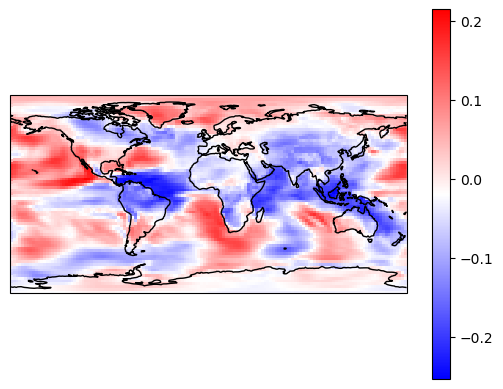

(<Figure size 640x480 with 2 Axes>, <GeoAxes: >)

In [122]:
plot_map(lat,lon,test['cov_Zi_R'][0][-1],central_longitude=0)

In [131]:
print(lat)
print(lon)

lat_SEP=(-35, -5)
lon_SEP=(-110, -70)
ilat_SEP, ilon_SEP = lat_lon_indices(lat, lon, lat_range=lat_SEP,lon_range=lon_SEP )
# print(ilon_SEP)
# print(ilat_SEP)
west_SEP = lon_SEP[0]
regional_lat_SEP = np.asarray(lat)[ilat_SEP]
regional_lon_SEP = west_SEP + (np.asarray(lon)[ilon_SEP] - west_SEP) % 360
order_SEP = np.argsort(regional_lon_SEP)
regional_lon_SEP = regional_lon_SEP[order_SEP]
print(regional_lat_SEP)
print(regional_lon_SEP)


lat_WPWP=(-10, 10)
lon_WPWP=(80, 150)
ilat_WPWP, ilon_WPWP = lat_lon_indices(lat, lon, lat_range=lat_WPWP,lon_range=lon_WPWP )
# print(ilon_WPWP)
# print(ilat_WPWP)
west_WPWP = lon_WPWP[0]
regional_lat_WPWP = np.asarray(lat)[ilat_WPWP]
regional_lon_WPWP = west_WPWP + (np.asarray(lon)[ilon_WPWP] - west_WPWP) % 360
order_WPWP = np.argsort(regional_lon_WPWP)
regional_lon_WPWP = regional_lon_WPWP[order_WPWP]
print(regional_lat_WPWP)
print(regional_lon_WPWP)


obs_cov_ZiR = overlap_observations['cov_Zi_R']
regional_obs_SEP            = np.take(np.take(obs_cov_ZiR, ilat_SEP, axis=-2), ilon_SEP, axis=-1)
regional_obs_plotting_SEP   = regional_obs_SEP[:, order_SEP]
regional_obs_WPWP            = np.take(np.take(obs_cov_ZiR, ilat_WPWP, axis=-2), ilon_WPWP, axis=-1)
regional_obs_plotting_WPWP   = regional_obs_WPWP[:, order_WPWP]


<xarray.DataArray 'lat' (lat: 72)> Size: 576B
array([-88.75, -86.25, -83.75, -81.25, -78.75, -76.25, -73.75, -71.25, -68.75,
       -66.25, -63.75, -61.25, -58.75, -56.25, -53.75, -51.25, -48.75, -46.25,
       -43.75, -41.25, -38.75, -36.25, -33.75, -31.25, -28.75, -26.25, -23.75,
       -21.25, -18.75, -16.25, -13.75, -11.25,  -8.75,  -6.25,  -3.75,  -1.25,
         1.25,   3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
        23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,  43.75,
        46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,  63.75,  66.25,
        68.75,  71.25,  73.75,  76.25,  78.75,  81.25,  83.75,  86.25,  88.75])
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         lat_bnds
<xarray.DataArray 'lon' (lon: 144)> Size: 1kB
array([  1.25,   3.75,   6.25,  

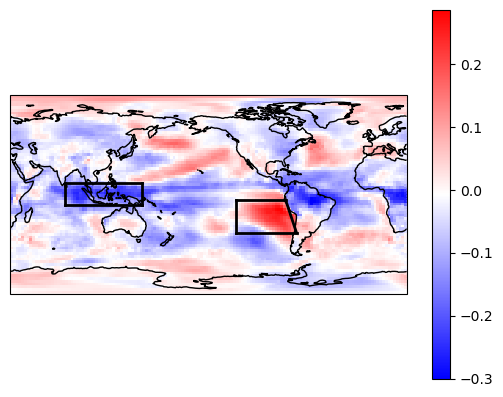

SEP / WPWP area = 1.0055 (+0.55%)


In [145]:
# Build full-grid coordinates. Negative longitudes make this Pacific box readable.
# Both coordinate arrays and the resulting masks have shape (lat, lon).
lon_signed = (np.asarray(lon) + 180) % 360 - 180
lon_2d, lat_2d = np.meshgrid(lon_signed, np.asarray(lat))

# First box: retain the latitude range, extend west, and slope the eastern edge.
# The eastern boundary moves westward as we go north.
south, north, west = -35., -5., -125.
east_at_south, east_at_north = -70., -80.
east_boundary = east_at_south + (
    (lat_2d - south) / (north - south)
) * (east_at_north - east_at_south)

mask_SEP = (
    (lat_2d >= south) & (lat_2d <= north)
    & (lon_2d >= west) & (lon_2d <= east_boundary)
)

# Second box: these boundaries select exactly the centers you listed.
mask_WPWP = (
    (lat_2d >= -10) & (lat_2d <= 10)
    & (lon_2d >= 80) & (lon_2d <= 150)
)


# Corners ordered around the perimeter; the function closes the outline.
boundary_SEP = [
    (west, south),
    (east_at_south, south),
    (east_at_north, north),
    (west, north),
]

# Draw the SEP trapezoid alongside the existing rectangular WPWP box.
plot_map(lat, lon, obs_cov_ZiR, central_longitude=210,
         vmin=vmin, vmax=vmax, boundary=boundary_SEP,
         lat_range=(-10, 10), lon_range=(80, 150))

# Optional: remove land using YOUR convention, 1 = land and NaN = ocean.
# Only use this if mask_land is aligned with this same full grid.
# ocean_mask = np.isnan(mask_land)
# mask_SEP &= ocean_mask
# mask_WPWP &= ocean_mask

# Compare selected areas. Cos(latitude) is proportional to cell area on this
# regular grid; recompute after land masking because that changes the comparison.
cell_weights = np.broadcast_to(np.cos(np.deg2rad(np.asarray(lat)))[:, None], mask_SEP.shape)
area_ratio = cell_weights[mask_SEP].sum() / cell_weights[mask_WPWP].sum()
print(f"SEP / WPWP area = {area_ratio:.4f} ({100 * (area_ratio - 1):+.2f}%)")

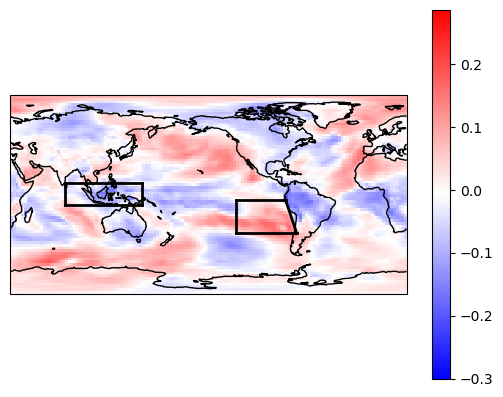

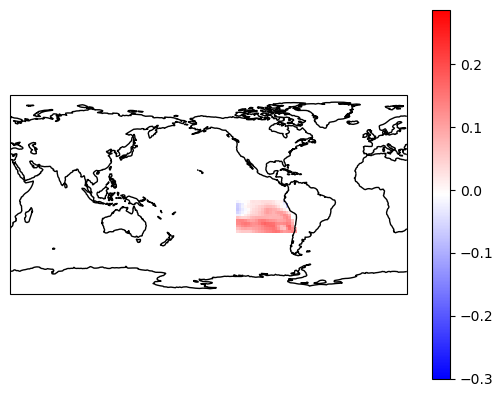

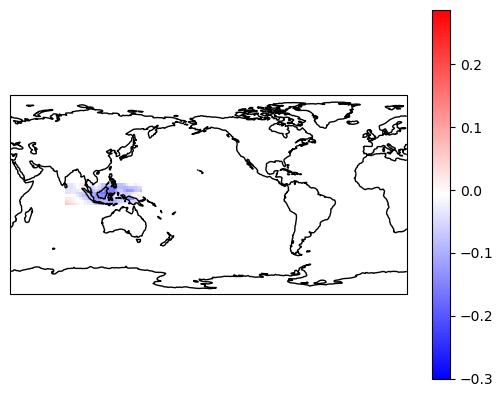

(<Figure size 640x480 with 2 Axes>, <GeoAxes: >)

In [148]:
full_map = test["cov_Zi_R"][0, 23]
SEP_values = np.where(mask_SEP, full_map, np.nan)
WPWP_values = np.where(mask_WPWP, full_map, np.nan)
vmin, vmax = np.nanmin(obs_cov_ZiR), np.nanmax(obs_cov_ZiR)

# Draw the SEP trapezoid alongside the existing rectangular WPWP box.
plot_map(lat, lon, full_map, central_longitude=210,
         vmin=vmin, vmax=vmax, boundary=boundary_SEP,
         lat_range=(-10, 10), lon_range=(80, 150))


plot_map(lat, lon, SEP_values, central_longitude=210,
        vmin=vmin, vmax=vmax)
plot_map(lat, lon, WPWP_values, central_longitude=210,
        vmin=vmin, vmax=vmax)

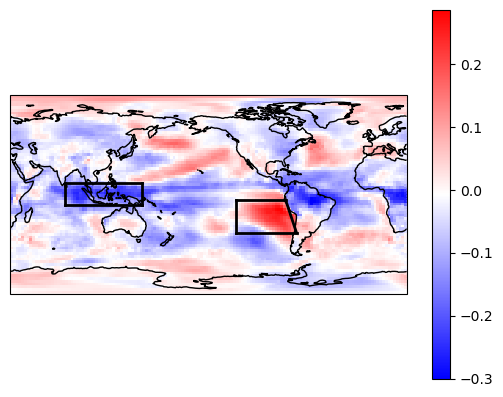

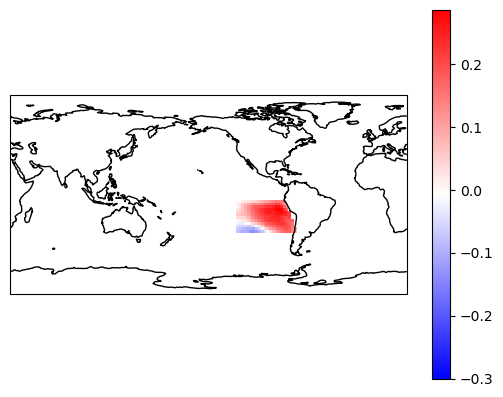

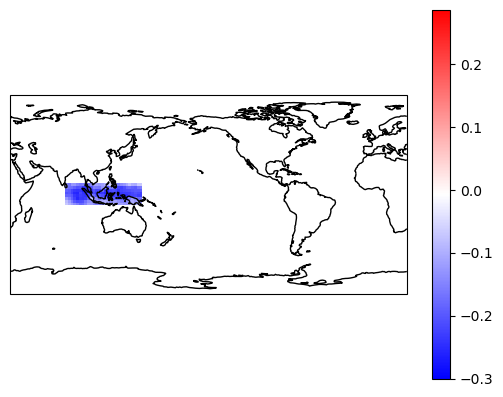

(<Figure size 640x480 with 2 Axes>, <GeoAxes: >)

In [147]:
# Broadcast across any preceding member/window axes; excluded cells become NaN.
SEP_obs = np.where(mask_SEP, obs_cov_ZiR, np.nan)
WPWP_obs = np.where(mask_WPWP, obs_cov_ZiR, np.nan)
vmin, vmax = np.nanmin(obs_cov_ZiR), np.nanmax(obs_cov_ZiR)

plot_map(lat, lon, obs_cov_ZiR, central_longitude=210,
         vmin=vmin, vmax=vmax, boundary=boundary_SEP,
         lat_range=(-10, 10), lon_range=(80, 150))

plot_map(lat, lon, SEP_obs, central_longitude=210,
        vmin=vmin, vmax=vmax)
plot_map(lat, lon, WPWP_obs, central_longitude=210,
        vmin=vmin, vmax=vmax)